# **Data Preparation**

In [ ]:
!pip install arch tensorflow optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 10.8 MB/s eta 0:00:00


In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import os
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_squared_error, mean_absolute_error

from scipy import stats
from arch import arch_model
from joblib import Parallel, delayed

import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input
from tensorflow.keras.optimizers import Adam


In [ ]:
!git clone https://github.com/maiht0101/regime-aware-volatility-forecasting.git

Cloning into 'regime-aware-volatility-forecasting'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 43 (delta 8), reused 19 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (43/43), 2.08 MiB | 4.71 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [ ]:
%cd regime-aware-volatility-forecasting

/content/regime-aware-volatility-forecasting


In [ ]:
# Load data
ndx = pd.read_pickle('data/processed/ndx.pkl')
ndx.head()

,Close,High,Low,Open,Volume,Returns,YZ_Vol,log_vol_1d,log_vol_5d,log_vol_22d,vxn_log,parkinson_vol_log,ema_5,ema_22,vol_5,vol_22
Date,,,,,,,,,,,,,,,,
2000-01-04,3546.199951,3766.570068,3542.729980,3766.570068,1511840000,-6.663455,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05,3507.310059,3576.169922,3371.750000,3543.129883,1735670000,-1.102722,NaN,NaN,NaN,NaN,NaN,-3.302402,NaN,NaN,NaN,NaN
2000-01-06,3340.810059,3513.550049,3334.020020,3488.310059,1598320000,-4.863607,NaN,NaN,NaN,NaN,NaN,-3.342476,NaN,NaN,NaN,NaN
2000-01-07,3529.600098,3529.750000,3314.750000,3337.260010,1634930000,5.497127,NaN,NaN,NaN,NaN,NaN,-3.457821,NaN,NaN,NaN,NaN
2000-01-10,3717.409912,3756.169922,3558.209961,3558.209961,1691710000,5.184259,NaN,NaN,NaN,NaN,NaN,-3.276977,NaN,NaN,NaN,NaN


In [ ]:
ndx.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6537 entries, 2000-01-04 to 2025-12-30
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Close              6537 non-null   float64
 1   High               6537 non-null   float64
 2   Low                6537 non-null   float64
 3   Open               6537 non-null   float64
 4   Volume             6537 non-null   int64  
 5   Returns            6537 non-null   float64
 6   YZ_Vol             6515 non-null   float64
 7   log_vol_1d         6514 non-null   float64
 8   log_vol_5d         6510 non-null   float64
 9   log_vol_22d        6493 non-null   float64
 10  vxn_log            6271 non-null   float64
 11  parkinson_vol_log  6536 non-null   float64
 12  ema_5              6514 non-null   float64
 13  ema_22             6514 non-null   float64
 14  vol_5              6532 non-null   float64
 15  vol_22             6515 non-null   float64
dtypes: flo

# **Predictive Variables on Train**

In [ ]:
# Dataframe for hybrid data
data = ndx[['YZ_Vol', 'Returns']].copy()

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6537 entries, 2000-01-04 to 2025-12-30
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   YZ_Vol   6515 non-null   float64
 1   Returns  6537 non-null   float64
dtypes: float64(2)
memory usage: 153.2 KB


In [ ]:
# drop nan values
data.dropna(inplace=True)

# Split to train and test
split = int(len(ndx[['Returns']]) * 0.9)

train = data[:split]
test = data[split:]

## **Fitting GARCH-typed Models**

In [ ]:
def process_single_config(model_spec, dist_type, returns_series, split_index, w_size=750):
    model_name, mean_type, vol_type, asym_order = model_spec
    config_id = f"{model_name}_{dist_type}"

    forecasted_volatilities = []
    forecasted_dates = []
    frozen_params = None

    # Adjust MAX_ALLOWED_VOL based on asset class (e.g., 15.0 daily vol = 225 variance)
    MAX_ALLOWED_VOL = 15.0
    MAX_ALLOWED_VAR = MAX_ALLOWED_VOL ** 2

    for t in range(split_index, len(returns_series)):
        current_date = returns_series.index[t]

        # Rolling window actively drops ancient data
        train_window = returns_series.iloc[t - w_size:t]
        model_lags = 1 if mean_type == "ARX" else None

        # Structural 22-day re-estimation checkpoint
        is_reestimation_day = ((t - split_index) % 22 == 0)

        if is_reestimation_day:
            model = arch_model(
                train_window, mean=mean_type, lags=model_lags,
                vol=vol_type, p=1, o=asym_order, q=1, dist=dist_type
            )

            result = None

            # ─── OPTIMIZATION STEP 1: Quasi-Newton Bounded Method (L-BFGS-B) ───
            try:
                fit_attempt = model.fit(disp='off', show_warning=False, method='L-BFGS-B')
                if np.isfinite(fit_attempt.params).all():
                    result = fit_attempt
            except Exception:
                result = None

            # ─── OPTIMIZATION STEP 2: Derivative-Free Fallback (Nelder-Mead) ────
            if result is None:
                try:
                    fit_attempt = model.fit(disp='off', show_warning=False, method='Nelder-Mead')
                    if np.isfinite(fit_attempt.params).all():
                        result = fit_attempt
                except Exception:
                    result = None

            # ─── OPTIMIZATION STEP 3: Default Solver (SLSQP) ───────────────────
            if result is None:
                try:
                    fit_attempt = model.fit(disp='off', show_warning=False)
                    if np.isfinite(fit_attempt.params).all():
                        result = fit_attempt
                except Exception:
                    result = None

            # ─── PARAMETER EVALUATION & VALIDATION ──────────────────────────────
            if result is not None:
                try:
                    # Safe convergence check using 'arch' package syntax
                    if hasattr(result, 'optimization_result') and not result.optimization_result.success:
                        raise ValueError("Optimizer did not converge cleanly.")

                    # --- CRITICAL FIX FOR EGARCH EXPLOSION ---
                    if vol_type.upper() == 'EGARCH':
                        beta_keys = [k for k in result.params.index if 'beta' in k]
                        if beta_keys:
                            beta_val = result.params[beta_keys[0]]
                            # Tightened persistence requirement to prevent exponential explosions
                            if abs(beta_val) >= 0.98:
                                raise ValueError(f"EGARCH persistence beta ({beta_val:.4f}) is unstable.")

                        # Fail-safe cap for historical conditional volatilities
                        if result.conditional_volatility.max() > MAX_ALLOWED_VOL:
                            raise ValueError("EGARCH produced unrealistic historical volatility spikes.")

                    # General non-EGARCH parameter explosion protection
                    if (result.params.abs() > 1e4).any() or not np.isfinite(result.loglikelihood):
                        raise ValueError("Parameters failed baseline boundary limits.")

                    # If it passes validation, store it safely
                    frozen_params = result.params

                except Exception as e:
                    if frozen_params is None:
                        print(f"Initial validation failed on asset at t={t}: {e}")
                    result = None

            # ─── OPERATIONAL SAFETY NET ─────────────────────────────────────────
            if result is None and frozen_params is None:
                # If we lack any working parameters to start with, we must skip
                continue

        # ─── RECURSIVE VOLATILITY UPDATING & FORECASTING STEP ───────────────────
        if frozen_params is not None:
            try:
                # Apply frozen parameters to the current moving window
                current_model = arch_model(
                    train_window, mean=mean_type, lags=model_lags,
                    vol=vol_type, p=1, o=asym_order, q=1, dist=dist_type
                )

                fixed_execution = current_model.fix(frozen_params)
                forecast = fixed_execution.forecast(horizon=1, reindex=False)
                sigma2 = forecast.variance.iloc[-1, 0]

                # Out-of-sample explosion filtering
                if not np.isfinite(sigma2) or sigma2 <= 0 or sigma2 > MAX_ALLOWED_VAR:
                    # Fallback to sample unconditional variance if the out-of-sample step explodes
                    sigma2 = train_window.var()

                forecasted_volatilities.append(np.sqrt(sigma2))
                forecasted_dates.append(current_date)

            except Exception as e:
                print(f"Error forecasting {config_id} at t={t}: {e}")
                # Secondary fallback to prevent empty indices in series
                try:
                    forecasted_volatilities.append(np.sqrt(train_window.var()))
                    forecasted_dates.append(current_date)
                except Exception:
                    continue

    # Clean compilation into indexed Pandas Series
    series_result = pd.Series(
        data=forecasted_volatilities, index=forecasted_dates, name=config_id
    )
    return config_id, series_result

### AR-GARCH-skewt

In [ ]:
# Define model specs matrix
model_specs_1 = [
    ("ARIMA-GARCH", "ARX", "GARCH", 0)
]

distributions = ["skewt"]

# Execute Parallel Processing
if __name__ == "__main__":
    # Generate the parameter grid combinations (Model Spec x Distribution Type)
    tasks = [
        (spec, dist)
        for spec in model_specs_1
        for dist in distributions
    ]

    print(f"Total model configurations to run in parallel: {len(tasks)}")

    # Run the optimized process_single_config function across CPU cores
    parallel_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(process_single_config)(
            model_spec=spec,
            dist_type=dist,
            returns_series=train['Returns'],
            split_index=750,
            w_size=750
        )
        for spec, dist in tasks
    )

    # Reconstruct master_storage and final DataFrame from the returned tuples
    master_storage = {config_id: series for config_id, series in parallel_results}
    df_results_garch = pd.DataFrame(master_storage)

    print("\nAll parallel tasks completed successfully.")
    print("--- Completed Forecast Matrix Shapes ---")
    print(df_results_garch.info())

Total model configurations to run in parallel: 1


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



All parallel tasks completed successfully.
--- Completed Forecast Matrix Shapes ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5133 entries, 2003-02-03 to 2023-06-23
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ARIMA-GARCH_skewt  5133 non-null   float64
dtypes: float64(1)
memory usage: 80.2 KB
None


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   56.8s


In [ ]:
df_results_garch.head()

,ARIMA-GARCH_skewt
2003-02-03,2.456007
2003-02-04,2.395515
2003-02-05,2.366486
2003-02-06,2.309335
2003-02-07,2.257049


In [ ]:
df_results_garch = df_results_garch.rename(columns={"ARIMA-GARCH_skewt": "volatility"})

### EGARCH

In [ ]:
# Define model specs matrix
model_specs_2 = [
    ("EGARCH", "Constant", "EGARCH", 1),
]

distributions = ["normal"]

# Execute Parallel Processing
if __name__ == "__main__":
    # Generate the parameter grid combinations (Model Spec x Distribution Type)
    tasks = [
        (spec, dist)
        for spec in model_specs_2
        for dist in distributions
    ]

    print(f"Total model configurations to run in parallel: {len(tasks)}")

    # Run the optimized process_single_config function across CPU cores
    parallel_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(process_single_config)(
            model_spec=spec,
            dist_type=dist,
            returns_series=train['Returns'],
            split_index=1000,
            w_size=1000
        )
        for spec, dist in tasks
    )

    # Reconstruct master_storage and final DataFrame from the returned tuples
    master_storage = {config_id: series for config_id, series in parallel_results}
    df_results_egarch = pd.DataFrame(master_storage)

    print("\nAll parallel tasks completed successfully.")
    print("--- Completed Forecast Matrix Shapes ---")
    print(df_results_egarch.info())

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Total model configurations to run in parallel: 1

All parallel tasks completed successfully.
--- Completed Forecast Matrix Shapes ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3959 entries, 2007-10-02 to 2023-06-23
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   EGARCH_normal  3959 non-null   float64
dtypes: float64(1)
memory usage: 61.9 KB
None


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   23.0s


In [ ]:
df_results_egarch.head()

,EGARCH_normal
2007-10-02,0.887704
2007-10-03,0.882063
2007-10-04,0.905736
2007-10-05,0.893919
2007-10-08,0.850290


In [ ]:
df_results_egarch = df_results_egarch.rename(columns={"EGARCH_normal": "volatility"})

### GJR-GARCH

In [ ]:
# Define model specs matrix
model_specs_3 = [
    ("GJR", "Constant", "GARCH", 1),
]

distributions = ["normal"]

# Execute Parallel Processing
if __name__ == "__main__":
    # Generate the parameter grid combinations (Model Spec x Distribution Type)
    tasks = [
        (spec, dist)
        for spec in model_specs_3
        for dist in distributions
    ]

    print(f"Total model configurations to run in parallel: {len(tasks)}")

    # Run the optimized process_single_config function across CPU cores
    parallel_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(process_single_config)(
            model_spec=spec,
            dist_type=dist,
            returns_series=train['Returns'],
            split_index=1000,
            w_size=1000
        )
        for spec, dist in tasks
    )

    # Reconstruct master_storage and final DataFrame from the returned tuples
    master_storage = {config_id: series for config_id, series in parallel_results}
    df_results_gjr = pd.DataFrame(master_storage)

    print("\nAll parallel tasks completed successfully.")
    print("--- Completed Forecast Matrix Shapes ---")
    print(df_results_gjr.info())

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Total model configurations to run in parallel: 1

All parallel tasks completed successfully.
--- Completed Forecast Matrix Shapes ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4883 entries, 2004-01-30 to 2023-06-23
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   GJR_normal  4883 non-null   float64
dtypes: float64(1)
memory usage: 76.3 KB
None


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   22.6s


In [ ]:
df_results_gjr.head()

,GJR_normal
2004-01-30,1.431670
2004-02-02,1.404402
2004-02-03,1.381128
2004-02-04,1.354733
2004-02-05,1.485709


In [ ]:
df_results_gjr = df_results_gjr.rename(columns={"GJR_normal": "volatility"})

## **Train Set**

In [ ]:
# adding predictive variables
# predicted volatility
train = train.copy()
train['garch_vol'] = df_results_garch['volatility'].copy()
train['egarch_vol'] = df_results_egarch['volatility'].copy()
train['gjr_vol'] = df_results_gjr['volatility'].copy()

# lag of RV
log_vol = np.log(train['YZ_Vol'])
train['log_vol_1d'] = log_vol.shift(1)
train['log_vol_5d'] = log_vol.rolling(5).mean().shift(1)
train['log_vol_22d'] = log_vol.rolling(22).mean().shift(1)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5883 entries, 2000-02-04 to 2023-06-23
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YZ_Vol       5883 non-null   float64
 1   Returns      5883 non-null   float64
 2   garch_vol    5133 non-null   float64
 3   egarch_vol   3959 non-null   float64
 4   gjr_vol      4883 non-null   float64
 5   log_vol_1d   5882 non-null   float64
 6   log_vol_5d   5878 non-null   float64
 7   log_vol_22d  5861 non-null   float64
dtypes: float64(8)
memory usage: 413.6 KB


In [ ]:
# keep only non-null values
train = train.dropna()
train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3959 entries, 2007-10-02 to 2023-06-23
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YZ_Vol       3959 non-null   float64
 1   Returns      3959 non-null   float64
 2   garch_vol    3959 non-null   float64
 3   egarch_vol   3959 non-null   float64
 4   gjr_vol      3959 non-null   float64
 5   log_vol_1d   3959 non-null   float64
 6   log_vol_5d   3959 non-null   float64
 7   log_vol_22d  3959 non-null   float64
dtypes: float64(8)
memory usage: 278.4 KB


In [ ]:
# define X_train and y_train
y_train = train['YZ_Vol'].copy()
X_train = train.drop(['YZ_Vol','Returns'], axis=1).copy()

In [ ]:
y_train.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 3959 entries, 2007-10-02 to 2023-06-23
Series name: YZ_Vol
Non-Null Count  Dtype  
--------------  -----  
3959 non-null   float64
dtypes: float64(1)
memory usage: 61.9 KB


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3959 entries, 2007-10-02 to 2023-06-23
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   garch_vol    3959 non-null   float64
 1   egarch_vol   3959 non-null   float64
 2   gjr_vol      3959 non-null   float64
 3   log_vol_1d   3959 non-null   float64
 4   log_vol_5d   3959 non-null   float64
 5   log_vol_22d  3959 non-null   float64
dtypes: float64(6)
memory usage: 216.5 KB


array([[<Axes: xlabel='Date'>, <Axes: xlabel='Date'>],
       [<Axes: xlabel='Date'>, <Axes: xlabel='Date'>],
       [<Axes: xlabel='Date'>, <Axes: xlabel='Date'>]], dtype=object)

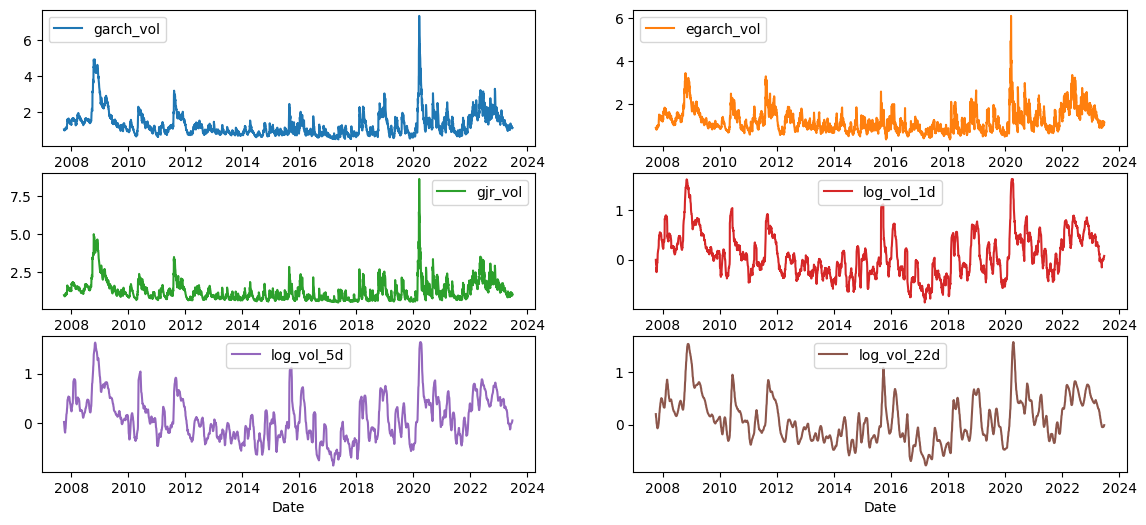

In [ ]:
# plot X_train
X_train.plot(
    subplots=True,
    layout=(3, int(np.ceil(len(X_train.columns)/3))),
    figsize=(14, 6),
    sharex=False
)


In [ ]:
# Transform predicted volatilities
X_train['log_garch_vol'] = np.log(X_train['garch_vol']) + 1e-8
X_train['log_egarch_vol'] = np.log(X_train['egarch_vol']) + 1e-8
X_train['log_gjr_vol'] = np.log(X_train['gjr_vol']) + 1e-8

In [ ]:
# Keep only log volatilites
X_train = X_train.drop(['garch_vol', 'egarch_vol', 'gjr_vol'], axis=1)
X_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3959 entries, 2007-10-02 to 2023-06-23
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   log_vol_1d      3959 non-null   float64
 1   log_vol_5d      3959 non-null   float64
 2   log_vol_22d     3959 non-null   float64
 3   log_garch_vol   3959 non-null   float64
 4   log_egarch_vol  3959 non-null   float64
 5   log_gjr_vol     3959 non-null   float64
dtypes: float64(6)
memory usage: 216.5 KB


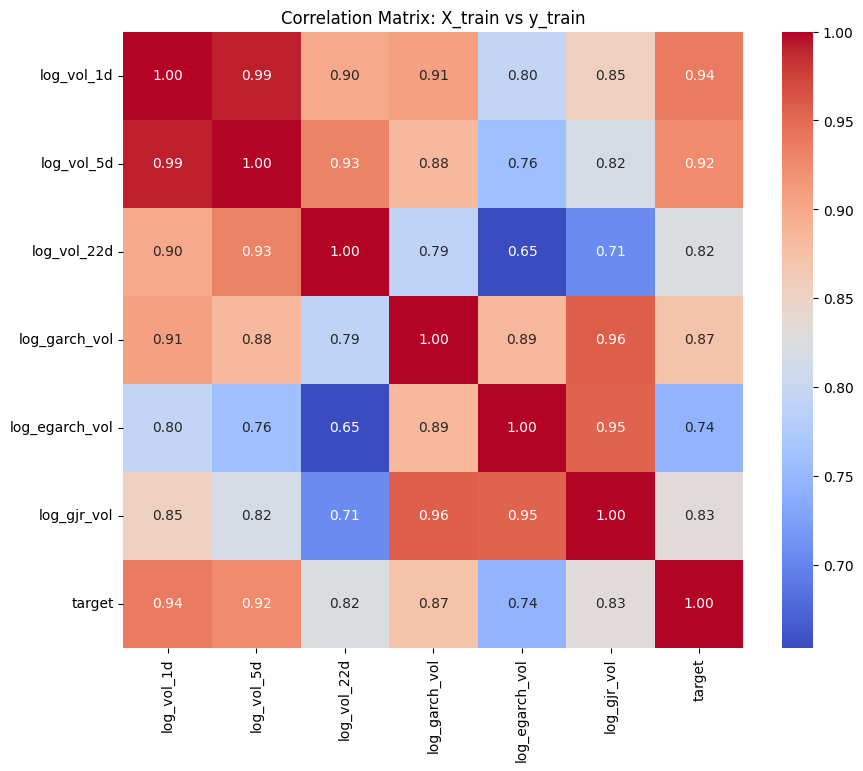

In [ ]:
df_corr = pd.concat([X_train, y_train.rename("target")], axis=1)

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: X_train vs y_train")
plt.savefig("corr_matrix_hybrid.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# delete log_vol_5d
X_train = X_train.drop(['log_vol_5d'], axis=1)
X_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3959 entries, 2007-10-02 to 2023-06-23
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   log_vol_1d      3959 non-null   float64
 1   log_vol_22d     3959 non-null   float64
 2   log_garch_vol   3959 non-null   float64
 3   log_egarch_vol  3959 non-null   float64
 4   log_gjr_vol     3959 non-null   float64
dtypes: float64(5)
memory usage: 185.6 KB


In [ ]:
# define the list of features to scale
features_to_scale = X_train.columns

# **Train LSTM**

In [ ]:
def create_sequences(features, targets, seq_length):
    features_arr = np.asarray(features)
    targets_arr = np.asarray(targets)

    # Number of sliding sequences we can create
    num_sequences = len(features_arr) - seq_length

    # Generate X using NumPy stride tricks
    shape = (num_sequences, seq_length, features_arr.shape[1])
    strides = (features_arr.strides[0], features_arr.strides[0], features_arr.strides[1])
    X = np.lib.stride_tricks.as_strided(features_arr, shape=shape, strides=strides)

    # Generate y directly aligned to the end of each sequence
    y = targets_arr[seq_length:]

    return X, y

In [ ]:
# Define walk-forward splits
def generate_walk_forward_splits(total_size, initial_train_size, val_size, step_size):
    splits = []

    start = 0
    while start + initial_train_size + val_size <= total_size:
        train_start = start
        train_end = start + initial_train_size
        val_end = train_end + val_size

        splits.append((train_start, train_end, train_end, val_end))
        start += step_size

    return splits

In [ ]:
# ROLLING WINDOW HYPERPARAMETER TUNING
def build_lstm(hp_dict, input_shape):
    # Determine the number of layers (defaults to 2 if not provided for backwards compatibility)
    num_layers = hp_dict.get('num_layers', 2)

    model = Sequential()
    model.add(Input(shape=input_shape))

    if num_layers == 1:
        # 1-Layer LSTM setup
        model.add(LSTM(units=hp_dict['units'], return_sequences=False))
        model.add(Dropout(hp_dict['dropout']))
    else:
        # 2-Layer LSTM setup
        model.add(LSTM(units=hp_dict['units'], return_sequences=True))
        model.add(Dropout(hp_dict['dropout']))
        model.add(LSTM(units=hp_dict['units'], return_sequences=False))
        model.add(Dropout(hp_dict['dropout']))

    # Output layer
    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=hp_dict['lr']),
        loss='mae'
    )
    return model

In [ ]:
def objective(trial):
    # Hyperparameter Search Space
    hp_dict = {
    # Sequence & Architecture Dynamics
    'num_layers': trial.suggest_categorical('num_layers', [1, 2]),
    'units': trial.suggest_categorical('units', [32, 64, 128, 256]),

    # Regularization
    'dropout': trial.suggest_categorical('dropout', [0.1, 0.2, 0.3, 0.4]),
    'recurrent_dropout': trial.suggest_categorical('recurrent_dropout', [0.0, 0.1, 0.2]),

    # Optimization
    'lr': trial.suggest_categorical('lr', [1e-3, 5e-3, 1e-2, 5e-2, 1e-4, 5e-4])}

    # Print the hyperparameters Optuna chose for this specific run
    print(f"Parameters selected: {hp_dict}")

    splits = generate_walk_forward_splits(
        total_size=len(X_train),
        initial_train_size=initial_train_size,
        val_size=val_size,
        step_size=step_size
    )

    fold_losses = []

    for fold, (train_start, train_end, val_start, val_end) in enumerate(splits):
        print(f"  → Processing Fold {fold + 1}/{len(splits)}...", end="", flush=True)

        # Prevent data leakage: Split raw frames first
        df_train = X_train.iloc[train_start:train_end].copy()
        df_val = X_train.iloc[val_start:val_end].copy()

        # Fresh scalers per fold
        scaler_std = StandardScaler()

        # Fit ONLY on training fold, transform both
        df_train[features_to_scale] = scaler_std.fit_transform(df_train[features_to_scale])

        df_val[features_to_scale] = scaler_std.transform(df_val[features_to_scale])

        # Consolidate features
        X_train_raw = df_train[features_to_scale].values
        y_train_raw = y_train.iloc[train_start:train_end].values
        X_val_raw = df_val[features_to_scale].values
        y_val_raw = y_train.iloc[val_start:val_end].values

        # Fast sequence generation
        X_train_seq, y_train_seq = create_sequences(X_train_raw, y_train_raw, lookback)
        X_val_seq, y_val_seq = create_sequences(X_val_raw, y_val_raw, lookback)

        if len(X_train_seq) == 0 or len(X_val_seq) == 0:
            continue

        # Build and fit LSTM
        input_shape = (lookback, X_train_seq.shape[2])
        model = build_lstm(hp_dict, input_shape)

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )

        model.fit(
            X_train_seq, y_train_seq,
            validation_data=(X_val_seq, y_val_seq),
            epochs=10,
            batch_size=64,
            verbose=0,
            callbacks=[early_stop]
        )

        val_loss = model.evaluate(X_val_seq, y_val_seq, verbose=0)
        fold_losses.append(val_loss)

        # Print the score for the completed fold
        print(f" Done. Val MAE: {val_loss:.4f}")

        # Report intermediate performance to Optuna for cross-fold pruning
        trial.report(val_loss, step=fold)
        if trial.should_prune():
            print(f"Trial #{trial.number} pruned early at fold {fold + 1} due to poor performance.")
            tf.keras.backend.clear_session()
            raise optuna.TrialPruned()

    # Clear RAM/VRAM memory graphs to prevent slowdowns over time
    tf.keras.backend.clear_session()

    mean_loss = np.mean(fold_losses) if fold_losses else float('inf')
    # 3. Print the final summary of the completed trial
    print(f"Trial #{trial.number} Finished. Average Cross-Val MAE: {mean_loss:.4f}")

    return mean_loss

In [ ]:
if __name__ == "__main__":
    # Global Parameters Configuration
    lookback = 22
    initial_train_size = 1500
    val_size = 126
    step_size = 126

    # Initialize optimization study with a Median Pruner
    study = optuna.create_study(
        direction="minimize",
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5)
    )

    # Run tuning
    study.optimize(objective, n_trials=15)

    print("\n--- TUNING COMPLETE ---")
    print("Best Trial Hyperparameters:", study.best_trial.params)
    print("Best Cross-Validated MAE:", study.best_value)

[I 2026-08-22 17:32:13,961] A new study created in memory with name: no-name-4303b72c-34d3-4b37-b1c7-60fda4bbb52d


Parameters selected: {'num_layers': 2, 'units': 256, 'dropout': 0.1, 'recurrent_dropout': 0.0, 'lr': 0.0001}
  → Processing Fold 1/19...

I0000 00:00:1787419935.818852      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787419935.821954      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


 Done. Val MAE: 0.0492
  → Processing Fold 2/19... Done. Val MAE: 0.0486
  → Processing Fold 3/19... Done. Val MAE: 0.1019
  → Processing Fold 4/19... Done. Val MAE: 0.1857
  → Processing Fold 5/19... Done. Val MAE: 0.1027
  → Processing Fold 6/19... Done. Val MAE: 0.0942
  → Processing Fold 7/19... Done. Val MAE: 0.0556
  → Processing Fold 8/19... Done. Val MAE: 0.0656
  → Processing Fold 9/19... Done. Val MAE: 0.1027
  → Processing Fold 10/19... Done. Val MAE: 0.0530
  → Processing Fold 11/19... Done. Val MAE: 0.0718
  → Processing Fold 12/19... Done. Val MAE: 0.1405
  → Processing Fold 13/19... Done. Val MAE: 0.1915
  → Processing Fold 14/19... Done. Val MAE: 0.1294
  → Processing Fold 15/19... Done. Val MAE: 0.1319
  → Processing Fold 16/19... Done. Val MAE: 0.0618
  → Processing Fold 17/19... Done. Val MAE: 0.0856
  → Processing Fold 18/19... Done. Val MAE: 0.1372
  → Processing Fold 19/19... Done. Val MAE: 0.0844


[I 2026-08-22 17:33:55,661] Trial 0 finished with value: 0.09964455193594883 and parameters: {'num_layers': 2, 'units': 256, 'dropout': 0.1, 'recurrent_dropout': 0.0, 'lr': 0.0001}. Best is trial 0 with value: 0.09964455193594883.


...

Trial #12 Finished. Average Cross-Val MAE: 0.0571
Parameters selected: {'num_layers': 1, 'units': 128, 'dropout': 0.2, 'recurrent_dropout': 0.2, 'lr': 0.005}
  → Processing Fold 1/19... Done. Val MAE: 0.0264
  → Processing Fold 2/19... Done. Val MAE: 0.0305
  → Processing Fold 3/19... Done. Val MAE: 0.0523
  → Processing Fold 4/19... Done. Val MAE: 0.0901
  → Processing Fold 5/19... Done. Val MAE: 0.0487
  → Processing Fold 6/19... Done. Val MAE: 0.0470
  → Processing Fold 7/19... Done. Val MAE: 0.0276
  → Processing Fold 8/19... Done. Val MAE: 0.0367
  → Processing Fold 9/19... Done. Val MAE: 0.0480
  → Processing Fold 10/19... Done. Val MAE: 0.0296
  → Processing Fold 11/19... Done. Val MAE: 0.0706
  → Processing Fold 12/19... Done. Val MAE: 0.0467
  → Processing Fold 13/19... Done. Val MAE: 0.0920
  → Processing Fold 14/19... Done. Val MAE: 0.0890
  → Processing Fold 15/19... Done. Val MAE: 0.0673
  → Processing Fold 16/19... Done. Val MAE: 0.0369
  → Processing Fold 17/19... Done. 

[I 2026-08-22 17:49:20,825] Trial 13 finished with value: 0.05487685483929358 and parameters: {'num_layers': 1, 'units': 128, 'dropout': 0.2, 'recurrent_dropout': 0.2, 'lr': 0.005}. Best is trial 13 with value: 0.05487685483929358.


Trial #13 Finished. Average Cross-Val MAE: 0.0549
Parameters selected: {'num_layers': 1, 'units': 128, 'dropout': 0.2, 'recurrent_dropout': 0.2, 'lr': 0.005}
  → Processing Fold 1/19... Done. Val MAE: 0.0326
  → Processing Fold 2/19... Done. Val MAE: 0.0283
  → Processing Fold 3/19... Done. Val MAE: 0.0495
  → Processing Fold 4/19... Done. Val MAE: 0.1061
  → Processing Fold 5/19... Done. Val MAE: 0.0495
  → Processing Fold 6/19... Done. Val MAE: 0.0498
  → Processing Fold 7/19... Done. Val MAE: 0.0304
  → Processing Fold 8/19... Done. Val MAE: 0.0391
  → Processing Fold 9/19... Done. Val MAE: 0.0564
  → Processing Fold 10/19... Done. Val MAE: 0.0326
  → Processing Fold 11/19... Done. Val MAE: 0.0603
  → Processing Fold 12/19... Done. Val MAE: 0.0546
  → Processing Fold 13/19... Done. Val MAE: 0.0944
  → Processing Fold 14/19... Done. Val MAE: 0.0936
  → Processing Fold 15/19... Done. Val MAE: 0.0553
  → Processing Fold 16/19... Done. Val MAE: 0.0353
  → Processing Fold 17/19... Done. 

[I 2026-08-22 17:50:31,236] Trial 14 finished with value: 0.0556637086954556 and parameters: {'num_layers': 1, 'units': 128, 'dropout': 0.2, 'recurrent_dropout': 0.2, 'lr': 0.005}. Best is trial 13 with value: 0.05487685483929358.


Trial #14 Finished. Average Cross-Val MAE: 0.0557

--- TUNING COMPLETE ---
Best Trial Hyperparameters: {'num_layers': 1, 'units': 128, 'dropout': 0.2, 'recurrent_dropout': 0.2, 'lr': 0.005}
Best Cross-Validated MAE: 0.05487685483929358


# **Refit on train set**

In [ ]:
# FIT FINAL GLOBAL SCALERS ON TRAIN DATA ONLY
# Scale features
vol_scaler_std = StandardScaler()

# Map and FIT on the final train block
X_final_train_scaled = vol_scaler_std.fit_transform(X_train[features_to_scale])


In [ ]:
# FORMAT INTO 3D TENSORS (SAMPLES, TIME STEPS, FEATURES)
lookback = 22

X_train_final, y_train_final = create_sequences(X_final_train_scaled, y_train, lookback)

print(f"Final Production Training Shapes:")
print(f"Features (X): {X_train_final.shape}")
print(f"Targets  (y): {y_train_final.shape}")

Final Production Training Shapes:
Features (X): (3916, 22, 5)
Targets  (y): (3916,)


In [ ]:
# INSTANTIATE & TRAIN THE CHOSEN PRODUCTION MODEL
best_hps = study.best_trial.params

input_shape = (lookback, X_train_final.shape[2])
final_model = build_lstm(best_hps, input_shape)

early_stop_final = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=7,
    restore_best_weights=True
)

print("\nTraining production model on full historical training data...")
# We train for slightly more epochs since we are utilizing more data at once
final_model.fit(
    X_train_final,
    y_train_final,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop_final],
    shuffle=False,
    verbose=1
)

print("\nStep 1 Complete! The production model is fully optimized and trained.")


Training production model on full historical training data...
Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4731
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1638
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1438
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1372
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1129
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1190
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1162
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0997
Epoch 9/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0923
Epoch 10/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0866
Epoch 11/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0898
Epoch 12/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0920
Epoch 13/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0969
Epoch 14/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0927
Epoch 15/50
62/62 ━━━━

In [ ]:
final_model.save("/kaggle/working/final_hybrid.keras")

# **Predictive Variables on Test**

## **Fitting GARCH-typed Models**

###AR-GARCH-skewt

In [ ]:
# Define model specs matrix
model_specs_1 = [
    ("ARIMA-GARCH", "ARX", "GARCH", 0)
]

distributions = ["skewt"]

# Execute Parallel Processing
if __name__ == "__main__":
    # Generate the parameter grid combinations (Model Spec x Distribution Type)
    tasks = [
        (spec, dist)
        for spec in model_specs_1
        for dist in distributions
    ]

    print(f"Total model configurations to run in parallel: {len(tasks)}")

    # Run the optimized process_single_config function across CPU cores
    parallel_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(process_single_config)(
            model_spec=spec,
            dist_type=dist,
            returns_series=data['returns'],
            split_index=split,
            w_size=750
        )
        for spec, dist in tasks
    )

    # Reconstruct master_storage and final DataFrame from the returned tuples
    master_storage = {config_id: series for config_id, series in parallel_results}
    df_test_garch = pd.DataFrame(master_storage)

    print("\nAll parallel tasks completed successfully.")
    print("--- Completed Forecast Matrix Shapes ---")
    print(df_test_garch.info())

Total model configurations to run in parallel: 1


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.



All parallel tasks completed successfully.
--- Completed Forecast Matrix Shapes ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 632 entries, 2023-06-26 to 2025-12-30
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ARIMA-GARCH_skewt  632 non-null    float64
dtypes: float64(1)
memory usage: 9.9 KB
None


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    5.4s


In [ ]:
df_test_garch = df_test_garch.rename(columns={"ARIMA-GARCH_skewt": "volatility"})
df_test_garch.head()

,volatility
2023-06-26,1.139715
2023-06-27,1.181304
2023-06-28,1.225298
2023-06-29,1.177010
2023-06-30,1.133980


###EGARCH

In [ ]:
# Define model specs matrix
model_specs_2 = [
    ("EGARCH", "Constant", "EGARCH", 1),
]

distributions = ["t"]

# Execute Parallel Processing
if __name__ == "__main__":
    # Generate the parameter grid combinations (Model Spec x Distribution Type)
    tasks = [
        (spec, dist)
        for spec in model_specs_2
        for dist in distributions
    ]

    print(f"Total model configurations to run in parallel: {len(tasks)}")

    # Run the optimized process_single_config function across CPU cores
    parallel_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(process_single_config)(
            model_spec=spec,
            dist_type=dist,
            returns_series=data['returns'],
            split_index=split,
            w_size=1000
        )
        for spec, dist in tasks
    )

    # Reconstruct master_storage and final DataFrame from the returned tuples
    master_storage = {config_id: series for config_id, series in parallel_results}
    df_test_egarch = pd.DataFrame(master_storage)

    print("\nAll parallel tasks completed successfully.")
    print("--- Completed Forecast Matrix Shapes ---")
    print(df_test_egarch.info())

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


Total model configurations to run in parallel: 1

All parallel tasks completed successfully.
--- Completed Forecast Matrix Shapes ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 632 entries, 2023-06-26 to 2025-12-30
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   EGARCH_t  632 non-null    float64
dtypes: float64(1)
memory usage: 9.9 KB
None


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    4.0s


In [ ]:
df_test_egarch = df_test_egarch.rename(columns={"EGARCH_t": "volatility"})
df_test_egarch.head()

,volatility
2023-06-26,1.222716
2023-06-27,1.393174
2023-06-28,1.336960
2023-06-29,1.235171
2023-06-30,1.186457


###GJR-GARCH

In [ ]:
# Define model specs matrix
model_specs_3 = [
    ("GJR", "Constant", "GARCH", 1),
]

distributions = ["skewt"]

# Execute Parallel Processing
if __name__ == "__main__":
    # Generate the parameter grid combinations (Model Spec x Distribution Type)
    tasks = [
        (spec, dist)
        for spec in model_specs_3
        for dist in distributions
    ]

    print(f"Total model configurations to run in parallel: {len(tasks)}")

    # Run the optimized process_single_config function across CPU cores
    parallel_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(process_single_config)(
            model_spec=spec,
            dist_type=dist,
            returns_series=data['returns'],
            split_index=split,
            w_size=1000
        )
        for spec, dist in tasks
    )

    # Reconstruct master_storage and final DataFrame from the returned tuples
    master_storage = {config_id: series for config_id, series in parallel_results}
    df_test_gjr = pd.DataFrame(master_storage)

    print("\nAll parallel tasks completed successfully.")
    print("--- Completed Forecast Matrix Shapes ---")
    print(df_test_gjr.info())

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


Total model configurations to run in parallel: 1

All parallel tasks completed successfully.
--- Completed Forecast Matrix Shapes ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 632 entries, 2023-06-26 to 2025-12-30
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   GJR_skewt  632 non-null    float64
dtypes: float64(1)
memory usage: 9.9 KB
None


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    4.8s


In [ ]:
df_test_gjr = df_test_gjr.rename(columns={"GJR_skewt": "volatility"})
df_test_gjr.head()

,volatility
2023-06-26,1.153975
2023-06-27,1.290211
2023-06-28,1.251682
2023-06-29,1.179188
2023-06-30,1.119425


##Test Set

In [ ]:
# adding predictive variables
# predicted volatility
test = test.copy()
test['garch_vol'] = df_test_garch['volatility']
test['egarch_vol'] = df_test_egarch['volatility']
test['gjr_vol'] = df_test_gjr['volatility']

# lag of RV
log_vol = np.log(test['YZ_Vol'])
test['log_vol_1d'] = log_vol.shift(1)
test['log_vol_22d'] = log_vol.rolling(22).mean().shift(1)


In [ ]:
# Transform predicted volatilities
test['log_garch_vol'] = np.log(test['garch_vol']) + 1e-8
test['log_egarch_vol'] = np.log(test['egarch_vol']) + 1e-8
test['log_gjr_vol'] = np.log(test['gjr_vol']) + 1e-8

In [ ]:
test = test.dropna()
test.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 632 entries, 2023-06-26 to 2025-12-30
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   YZ_Vol          632 non-null    float64
 1   returns         632 non-null    float64
 2   garch_vol       632 non-null    float64
 3   egarch_vol      632 non-null    float64
 4   gjr_vol         632 non-null    float64
 5   log_vol_1d      632 non-null    float64
 6   log_vol_22d     632 non-null    float64
 7   log_garch_vol   632 non-null    float64
 8   log_egarch_vol  632 non-null    float64
 9   log_gjr_vol     632 non-null    float64
dtypes: float64(10)
memory usage: 54.3 KB


In [ ]:
# define X_train and y_train
y_test = test['YZ_Vol'].copy()
X_test = test.drop(['YZ_Vol','returns'], axis=1).copy()

In [ ]:
y_test.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 632 entries, 2023-06-26 to 2025-12-30
Series name: YZ_Vol
Non-Null Count  Dtype  
--------------  -----  
632 non-null    float64
dtypes: float64(1)
memory usage: 9.9 KB


In [ ]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 632 entries, 2023-06-26 to 2025-12-30
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   garch_vol       632 non-null    float64
 1   egarch_vol      632 non-null    float64
 2   gjr_vol         632 non-null    float64
 3   log_vol_1d      632 non-null    float64
 4   log_vol_22d     632 non-null    float64
 5   log_garch_vol   632 non-null    float64
 6   log_egarch_vol  632 non-null    float64
 7   log_gjr_vol     632 non-null    float64
dtypes: float64(8)
memory usage: 44.4 KB


In [ ]:
# Keep only log volatilites
X_test = X_test.drop(['garch_vol', 'egarch_vol', 'gjr_vol'], axis=1)
X_test.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 632 entries, 2023-06-26 to 2025-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   log_vol_1d      632 non-null    float64
 1   log_vol_22d     632 non-null    float64
 2   log_garch_vol   632 non-null    float64
 3   log_egarch_vol  632 non-null    float64
 4   log_gjr_vol     632 non-null    float64
dtypes: float64(5)
memory usage: 29.6 KB


# **Out-of-sample Predictions**

In [ ]:
# SCALE THE RAW TEST SET FEATURES
X_final_test_scaled = vol_scaler_std.transform(X_test[features_to_scale])

In [ ]:
# FORMAT TEST FEATURES AND TARGETS INTO 3D SEQUENCES
X_test_final, y_test_final = create_sequences(X_final_test_scaled, y_test, lookback)

print(f"Final Out-of-Sample Test Shapes:")
print(f"Features (X): {X_test_final.shape}")
print(f"Targets  (y): {y_test_final.shape}")

Final Out-of-Sample Test Shapes:
Features (X): (610, 22, 5)
Targets  (y): (610,)


In [ ]:
# GENERATE OUT-OF-SAMPLE PREDICTIONS
print("\nGenerating out-of-sample predictions from the production model...")

# Predict the expected returns for tomorrow
final_predictions = final_model.predict(X_test_final)

# Flatten the predictions array for easier analysis later
final_predictions = final_predictions.flatten()

print(f"Step 2 Complete! Generated {len(final_predictions)} out-of-sample directional return forecasts.")
print(f"Sample Predictions (first 5): {final_predictions[:5]}")


Generating out-of-sample predictions from the production model...
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Step 2 Complete! Generated 610 out-of-sample directional return forecasts.
Sample Predictions (first 5): [0.931161   0.90000117 0.9462658  0.966859   0.93844163]


#**Evaluation Metrics**

In [ ]:
# Evaluation metrics definitiion

# QLIKE
def qlike(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    # 1. Safety: Avoid non-positive values that break np.log
    eps = 1e-9
    y_pred = np.maximum(y_pred, eps)
    y_true = np.maximum(y_true, eps)

    # 2. Calculation: Log(Pred) + (True / Pred)
    # This works for both scalars and vectors
    loss = np.log(y_pred) + (y_true / y_pred)

    # 3. Aggregation: Return the mean of the losses
    return np.mean(loss)

In [ ]:
# Get the dates belonging strictly to your test set
test_dates = data.index[split:]

# Slice the index from the tail end to match the exact length of your predictions
num_predictions = len(final_predictions)
prediction_dates = test_dates[-num_predictions:]

# Create a clean Pandas Series with the true index
df_predictions = pd.Series(
    data=final_predictions,
    index=prediction_dates,
    name="predicted_volatility"
)

# Combine everything into a clean comparison DataFrame
df_comparison = pd.DataFrame({
    "Actual Volatility": y_test_final,
    "Predicted Volatility": final_predictions
}, index=prediction_dates)

print(df_comparison.head())
print("-" * 35)
print(f"Total rows successfully matched: {len(df_comparison)}")

            Actual Volatility  Predicted Volatility
Date                                               
2023-07-27           0.958610              0.931161
2023-07-28           0.968396              0.900001
2023-07-31           0.945491              0.946266
2023-08-01           0.952689              0.966859
2023-08-02           0.980020              0.938442
-----------------------------------
Total rows successfully matched: 610


In [ ]:
print(df_comparison.head())
print(df_comparison.describe())

            Actual Volatility  Predicted Volatility
Date                                               
2023-07-27           0.958610              0.931161
2023-07-28           0.968396              0.900001
2023-07-31           0.945491              0.946266
2023-08-01           0.952689              0.966859
2023-08-02           0.980020              0.938442
       Actual Volatility  Predicted Volatility
count         610.000000            610.000000
mean            1.139772              1.143096
std             0.471053              0.454164
min             0.595275              0.628644
25%             0.861531              0.854082
50%             1.006692              1.016435
75%             1.217567              1.240280
max             3.155370              3.011194


In [ ]:
import pickle

df_comparison.to_pickle("/kaggle/working/hybrid_predict.pkl")

In [ ]:
y_test_pred = final_predictions
test_metrics = {
    "RMSE": np.sqrt(mean_squared_error(y_test_final, y_test_pred)),
    "MAE": mean_absolute_error(y_test_final, y_test_pred),
    "Qlike": qlike(y_test_final, y_test_pred)
}

test_metrics = pd.DataFrame(test_metrics, index=["Test"])
print(test_metrics.round(4))


        RMSE     MAE   Qlike
Test  0.0829  0.0506  1.0724


In [ ]:
# Make predictions on train set
y_train_pred = final_model.predict(X_train_final)

123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
train_metrics = {
    "RMSE": np.sqrt(mean_squared_error(y_train_final, y_train_pred)),
    "MAE": mean_absolute_error(y_train_final, y_train_pred),
    "Qlike": qlike(y_train_final, y_train_pred)
}

train_metrics = pd.DataFrame(train_metrics, index=["Train"])
print(train_metrics.round(4))

         RMSE     MAE  Qlike
Train  0.1217  0.0586  1.313
